<a href="https://colab.research.google.com/github/Dercypt/cc19-data-mining-project/blob/main/Copy_of_4_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 - Step 2: Model Training
## Heart Attack Risk Prediction using Logistic Regression

**Team Members:** AQUINO, Marinell | BAUTISTA, Esther Gabrielle | DULAY, Verah Janae | QUITALEG, Sean Zyndrex

**Section:** CITCS 2B

**Date:** 2026-02-21

## 1. Import Required Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✓ ALL LIBRARIES IMPORTED SUCCESSFULLY!")

✓ ALL LIBRARIES IMPORTED SUCCESSFULLY!


## 2. Load and Prepare the Dataset

In [32]:
# load the dataset directly from your GITHUB repository
url = "https://github.com/Dercypt/cc19-data-mining-project/raw/refs/heads/main/heart_attack_prediction_dataset.csv"

# read the CSV (comma separated values) file
df = pd.read_csv(url)

# dataset overview
print(f"✓ DATASET LOADED SUCCESSFULLY FROM GITHUB")
print(f"DATASET SHAPE: {df.shape}")
print(f"\nFEATURES/COLUMNS: {df.columns.tolist()}")
print(f"\nTARGET VARIABLE DISTRIBUTION:")
print(df['Heart Attack Risk'].value_counts())
print(f"\nCLASS BALANCE: {df['Heart Attack Risk'].value_counts(normalize=True)}")

✓ DATASET LOADED SUCCESSFULLY FROM GITHUB
DATASET SHAPE: (8763, 26)

FEATURES/COLUMNS: ['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere', 'Heart Attack Risk']

TARGET VARIABLE DISTRIBUTION:
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

CLASS BALANCE: Heart Attack Risk
0    0.641789
1    0.358211
Name: proportion, dtype: float64


## 3. Data Preprocessing

In [33]:
# Remove identifier columns that don't contribute to prediction
columns_to_drop = ['Patient ID', 'Country', 'Continent', 'Hemisphere']
df_clean = df.drop(columns=columns_to_drop)

print(f"Features after dropping identifiers: {df_clean.shape[1] - 1}") # -1 for target
print(f"Remaining columns: {df_clean.columns.tolist()}")

Features after dropping identifiers: 21
Remaining columns: ['Age', 'Sex', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk']


In [34]:
# Handle Blood Pressure (split into Systolic and Diastolic)
df_clean[['Systolic_BP', 'Diastolic_BP']] = df_clean['Blood Pressure'].str.split('/', expand=True).astype(int)
df_clean = df_clean.drop('Blood Pressure', axis=1)

print("✓ Blood Pressure split into Systolic and Diastolic")

✓ Blood Pressure split into Systolic and Diastolic


In [35]:
# Encode categorical variables
label_encoders = {}

# Sex: Male=1, Female=0
df_clean['Sex'] = df_clean['Sex'].map({'Male': 1, 'Female': 0})

# Diet: Unhealthy=0, Average=1, Healthy=2
df_clean['Diet'] = df_clean['Diet'].map({'Unhealthy': 0, 'Average': 1, 'Healthy': 2})

print("✓ Categorical variables encoded")
print(f"\nFinal feature set:")
print(df_clean.columns.tolist())

✓ Categorical variables encoded

Final feature set:
['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk', 'Systolic_BP', 'Diastolic_BP']


In [36]:
# Check for any missing values
print("Missing values per column:")
print(df_clean.isnull().sum())

# Check data types
print("\nData types:")
print(df_clean.dtypes)

Missing values per column:
Age                                0
Sex                                0
Cholesterol                        0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Heart Attack Risk                  0
Systolic_BP                        0
Diastolic_BP                       0
dtype: int64

Data types:
Age                                  int64
Sex                                  int64
Cholestero

## 4. Split Features and Target Variable

In [37]:
# Separate features (X) and target (y)
X = df_clean.drop('Heart Attack Risk', axis=1)
y = df_clean['Heart Attack Risk']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names ({len(X.columns)} total):")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

Features shape: (8763, 22)
Target shape: (8763,)

Feature names (22 total):
1. Age
2. Sex
3. Cholesterol
4. Heart Rate
5. Diabetes
6. Family History
7. Smoking
8. Obesity
9. Alcohol Consumption
10. Exercise Hours Per Week
11. Diet
12. Previous Heart Problems
13. Medication Use
14. Stress Level
15. Sedentary Hours Per Day
16. Income
17. BMI
18. Triglycerides
19. Physical Activity Days Per Week
20. Sleep Hours Per Day
21. Systolic_BP
22. Diastolic_BP


## 5. Train-Test Split (80/20)

In [38]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Maintains class distribution in both sets
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 7010 samples (80.0%)
Testing set size: 1753 samples (20.0%)

Training set class distribution:
Heart Attack Risk
0    4499
1    2511
Name: count, dtype: int64

Testing set class distribution:
Heart Attack Risk
0    1125
1     628
Name: count, dtype: int64


## 6. Feature Scaling

Logistic Regression is sensitive to feature scales, so we standardize the features.

In [39]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized (scaled)")
print(f"\nSample of scaled training data (first 5 features of first sample):")
print(X_train_scaled[0, :5])

✓ Features standardized (scaled)

Sample of scaled training data (first 5 features of first sample):
[-1.54117005  0.65910382 -0.12804283  0.14343647  0.73829116]


## 7. Train Baseline Logistic Regression Model

In [40]:
# Train baseline Logistic Regression with default parameters
# When training the model, add class_weight='balanced'
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight={0: 1, 1: 2}  # Give 2x weight to High Risk class
)

baseline_model.fit(X_train_scaled, y_train)

print("✓ Baseline Logistic Regression model trained successfully!")
print(f"\nModel parameters:")
print(f"- Solver: {baseline_model.solver}")
print(f"- Penalty: {baseline_model.penalty}")
print(f"- C (regularization): {baseline_model.C}")

✓ Baseline Logistic Regression model trained successfully!

Model parameters:
- Solver: lbfgs
- Penalty: l2
- C (regularization): 1.0


## 8. Make Predictions on Test Set

In [41]:
# Predict on test set
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Get probabilities
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Use lower threshold (e.g., 0.3 instead of 0.5)
y_pred_adjusted = (y_pred_proba >= 0.3).astype(int)

# Evaluate
recall_adjusted = recall_score(y_test, y_pred_adjusted)

print(f"Recall with 0.3 threshold: {recall_adjusted:.4f}")
print("✓ Predictions generated")
print(f"\nFirst 10 predictions:")
print(f"Actual:    {y_test.values[:10]}")
print(f"Predicted: {y_pred_baseline[:10]}")

Recall with 0.3 threshold: 1.0000
✓ Predictions generated

First 10 predictions:
Actual:    [0 0 0 1 0 1 1 0 1 0]
Predicted: [0 1 1 1 1 1 1 1 1 1]


## 9. Evaluate Baseline Model Performance

In [42]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
roc_auc = roc_auc_score(y_test, y_pred_baseline)

print("=" * 60)
print("BASELINE MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%) ← PRIORITY METRIC")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 60)

print(f"\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_baseline, target_names=['Low Risk', 'High Risk']))

BASELINE MODEL PERFORMANCE METRICS
Accuracy:  0.4124 (41.24%)
Precision: 0.3596 (35.96%)
Recall:    0.8201 (82.01%) ← PRIORITY METRIC
F1-Score:  0.5000 (50.00%)
ROC-AUC:   0.5025

📊 Classification Report:

              precision    recall  f1-score   support

    Low Risk       0.65      0.18      0.29      1125
   High Risk       0.36      0.82      0.50       628

    accuracy                           0.41      1753
   macro avg       0.50      0.50      0.39      1753
weighted avg       0.54      0.41      0.36      1753



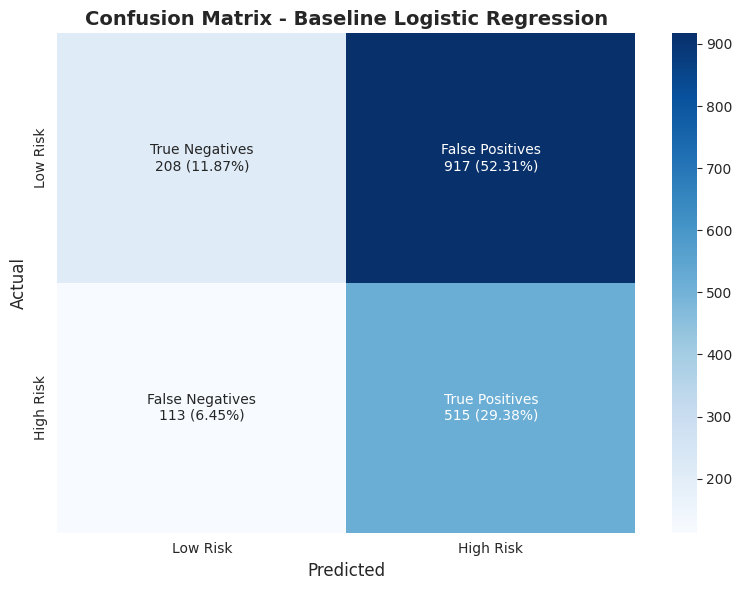


⚠️ False Negatives (missed heart attacks): 113
⚠️ False Positives (false alarms): 917


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)

# Calculate percentages based on total samples
total_samples = len(y_test)
cm_percentages = cm.astype('float') / total_samples * 100

# Create custom annotation array with counts and percentages
labels = np.empty_like(cm, dtype=object)
labels[0, 0] = f'True Negatives\n{cm[0,0]} ({cm_percentages[0,0]:.2f}%)'
labels[0, 1] = f'False Positives\n{cm[0,1]} ({cm_percentages[0,1]:.2f}%)'
labels[1, 0] = f'False Negatives\n{cm[1,0]} ({cm_percentages[1,0]:.2f}%)'
labels[1, 1] = f'True Positives\n{cm[1,1]} ({cm_percentages[1,1]:.2f}%)'

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=True,
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n⚠️ False Negatives (missed heart attacks): {cm[1,0]}")
print(f"⚠️ False Positives (false alarms): {cm[0,1]}")

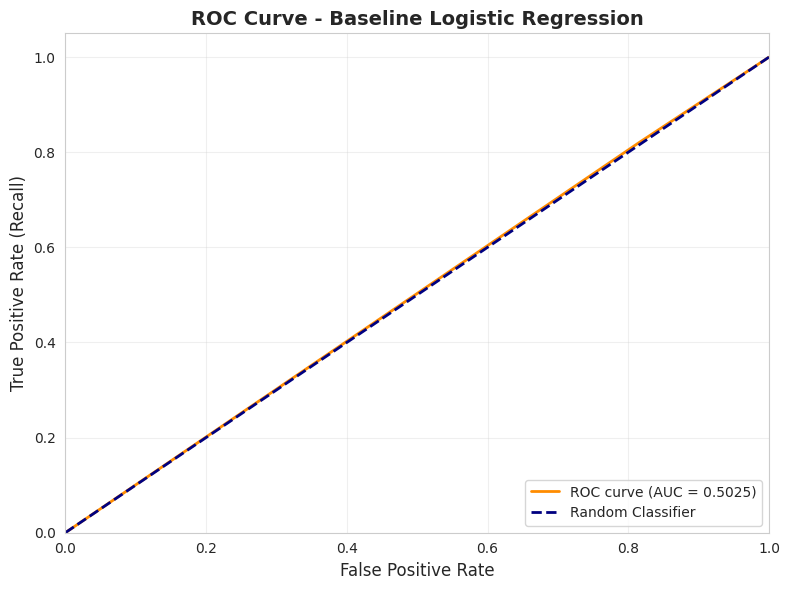

✓ ROC Curve generated. AUC Score: 0.5025


In [44]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Baseline Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ROC Curve generated. AUC Score: {roc_auc:.4f}")

## 10. Hyperparameter Tuning with GridSearchCV

We'll tune the following hyperparameters:
- **C**: Inverse of regularization strength (smaller values = stronger regularization)
- **penalty**: Type of regularization (L1 or L2)
- **solver**: Algorithm to use for optimization

In [45]:
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # ← Remove 0.01
    'penalty': ['l2'],  # ← Use only L2 (more stable than L1)
    'solver': ['lbfgs', 'liblinear'],  # ← lbfgs is better for L2
    'class_weight': [
        {0: 1, 1: 2.0},  # Keep what worked for baseline
    ]
}

# Create GridSearchCV object
# Using recall as scoring metric since we prioritize catching heart attacks
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',  # ← CHANGE THIS FROM 'recall' TO 'f1'
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
print(f"Total combinations to test: {len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver'])}")
print(f"With 5-fold CV, total fits: {len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver']) * 5}")

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

print("\n✓ GridSearchCV completed!")

Starting GridSearchCV...
Total combinations to test: 8
With 5-fold CV, total fits: 40
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✓ GridSearchCV completed!


In [46]:
# Display best parameters and score
print("=" * 60)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation recall score: {grid_search.best_score_:.4f}")
print("=" * 60)

# Get the best model
best_model = grid_search.best_estimator_

BEST HYPERPARAMETERS FOUND
Best parameters: {'C': 0.1, 'class_weight': {0: 1, 1: 2.0}, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation recall score: 0.4966


In [47]:
# Display top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]

print("\nTop 5 parameter combinations:")
print(top_5.to_string(index=False))

# Highlighting the stability of the model
avg_std = top_5['std_test_score'].mean()
print(f"\nAverage standard deviation of top 5: {avg_std:.4f}")
if avg_std < 0.05:
    print("✓ The search is stable across different folds.")
else:
    print("! Warning: High variance between folds; model may be sensitive to data splits.")


Top 5 parameter combinations:
                                                                            params  mean_test_score  std_test_score
    {'C': 0.1, 'class_weight': {0: 1, 1: 2.0}, 'penalty': 'l2', 'solver': 'lbfgs'}         0.496596        0.009803
{'C': 0.1, 'class_weight': {0: 1, 1: 2.0}, 'penalty': 'l2', 'solver': 'liblinear'}         0.496524        0.009632
     {'C': 10, 'class_weight': {0: 1, 1: 2.0}, 'penalty': 'l2', 'solver': 'lbfgs'}         0.496409        0.009539
    {'C': 100, 'class_weight': {0: 1, 1: 2.0}, 'penalty': 'l2', 'solver': 'lbfgs'}         0.496409        0.009539
      {'C': 1, 'class_weight': {0: 1, 1: 2.0}, 'penalty': 'l2', 'solver': 'lbfgs'}         0.496286        0.009714

Average standard deviation of top 5: 0.0096
✓ The search is stable across different folds.


## 11. Evaluate Tuned Model

In [48]:
# Make predictions with tuned model
y_pred_tuned = best_model.predict(X_test_scaled)
y_pred_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print("=" * 60)
print("TUNED MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")
print(f"Precision: {precision_tuned:.4f} ({precision_tuned*100:.2f}%)")
print(f"Recall:    {recall_tuned:.4f} ({recall_tuned*100:.2f}%) ← PRIORITY METRIC")
print(f"F1-Score:  {f1_tuned:.4f} ({f1_tuned*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc_tuned:.4f}")
print("=" * 60)

print(f"\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Low Risk', 'High Risk']))

TUNED MODEL PERFORMANCE METRICS
Accuracy:  0.4124 (41.24%)
Precision: 0.3598 (35.98%)
Recall:    0.8217 (82.17%) ← PRIORITY METRIC
F1-Score:  0.5005 (50.05%)
ROC-AUC:   0.4926

📊 Classification Report:

              precision    recall  f1-score   support

    Low Risk       0.65      0.18      0.29      1125
   High Risk       0.36      0.82      0.50       628

    accuracy                           0.41      1753
   macro avg       0.50      0.50      0.39      1753
weighted avg       0.55      0.41      0.36      1753



In [49]:
# Compare baseline vs tuned model
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline Model': [accuracy, precision, recall, f1, roc_auc],
    'Tuned Model': [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned, roc_auc_tuned],
    'Improvement': [
        accuracy_tuned - accuracy,
        precision_tuned - precision,
        recall_tuned - recall,
        f1_tuned - f1,
        roc_auc_tuned - roc_auc
    ]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON: BASELINE vs TUNED")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)


MODEL COMPARISON: BASELINE vs TUNED
   Metric  Baseline Model  Tuned Model  Improvement
 Accuracy        0.412436     0.412436     0.000000
Precision        0.359637     0.359833     0.000196
   Recall        0.820064     0.821656     0.001592
 F1-Score        0.500000     0.500485     0.000485
  ROC-AUC        0.502476     0.492556    -0.009920


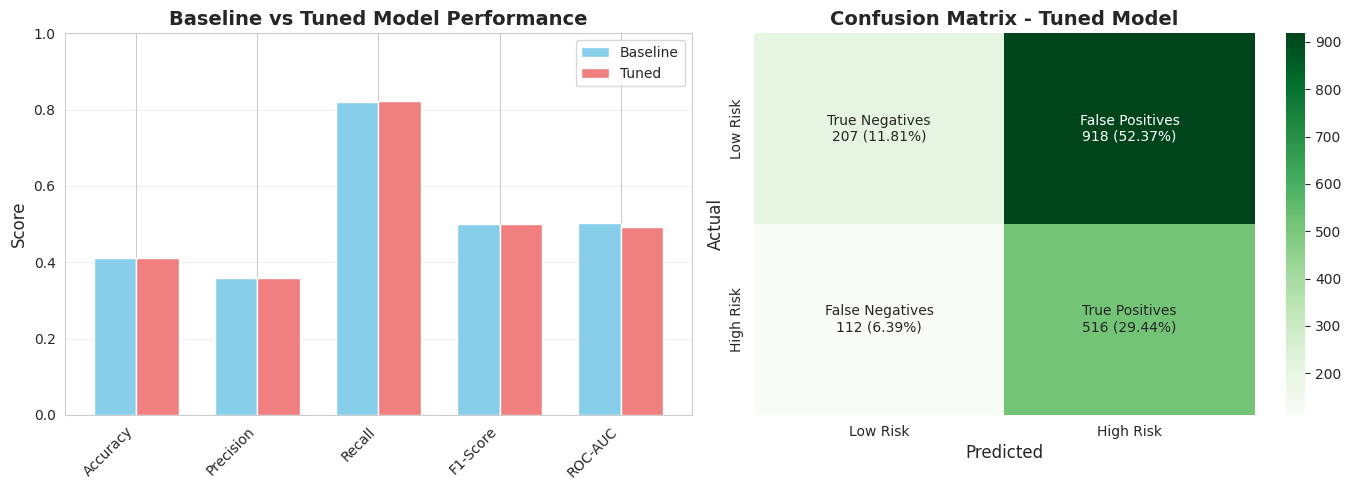


⚠️ Tuned Model - False Negatives (missed heart attacks): 112
⚠️ Tuned Model - False Positives (false alarms): 918


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = np.arange(len(comparison_df['Metric']))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Baseline Model'], width, label='Baseline', color='skyblue')
axes[0].bar(x + width/2, comparison_df['Tuned Model'], width, label='Tuned', color='lightcoral')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Baseline vs Tuned Model Performance', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Metric'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Calculate percentages based on total samples
total_samples_tuned = len(y_test)
cm_percentages_tuned = cm_tuned.astype('float') / total_samples_tuned * 100

# Create custom annotation array with counts and percentages for tuned model
labels_tuned = np.empty_like(cm_tuned, dtype=object)
labels_tuned[0, 0] = f'True Negatives\n{cm_tuned[0,0]} ({cm_percentages_tuned[0,0]:.2f}%)'
labels_tuned[0, 1] = f'False Positives\n{cm_tuned[0,1]} ({cm_percentages_tuned[0,1]:.2f}%)'
labels_tuned[1, 0] = f'False Negatives\n{cm_tuned[1,0]} ({cm_percentages_tuned[1,0]:.2f}%)'
labels_tuned[1, 1] = f'True Positives\n{cm_tuned[1,1]} ({cm_percentages_tuned[1,1]:.2f}%)'

sns.heatmap(cm_tuned, annot=labels_tuned, fmt='', cmap='Greens', cbar=True, ax=axes[1],
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
axes[1].set_title('Confusion Matrix - Tuned Model', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n⚠️ Tuned Model - False Negatives (missed heart attacks): {cm_tuned[1,0]}")
print(f"⚠️ Tuned Model - False Positives (false alarms): {cm_tuned[0,1]}")

## 12. Cross-Validation Analysis

Evaluate model consistency across different data splits.

5-FOLD CROSS-VALIDATION RESULTS
Accuracy:  0.4240 (+/- 0.0068)
Precision: 0.3614 (+/- 0.0087)
Recall:    0.7937 (+/- 0.0590)
F1-Score:  0.4966 (+/- 0.0196)


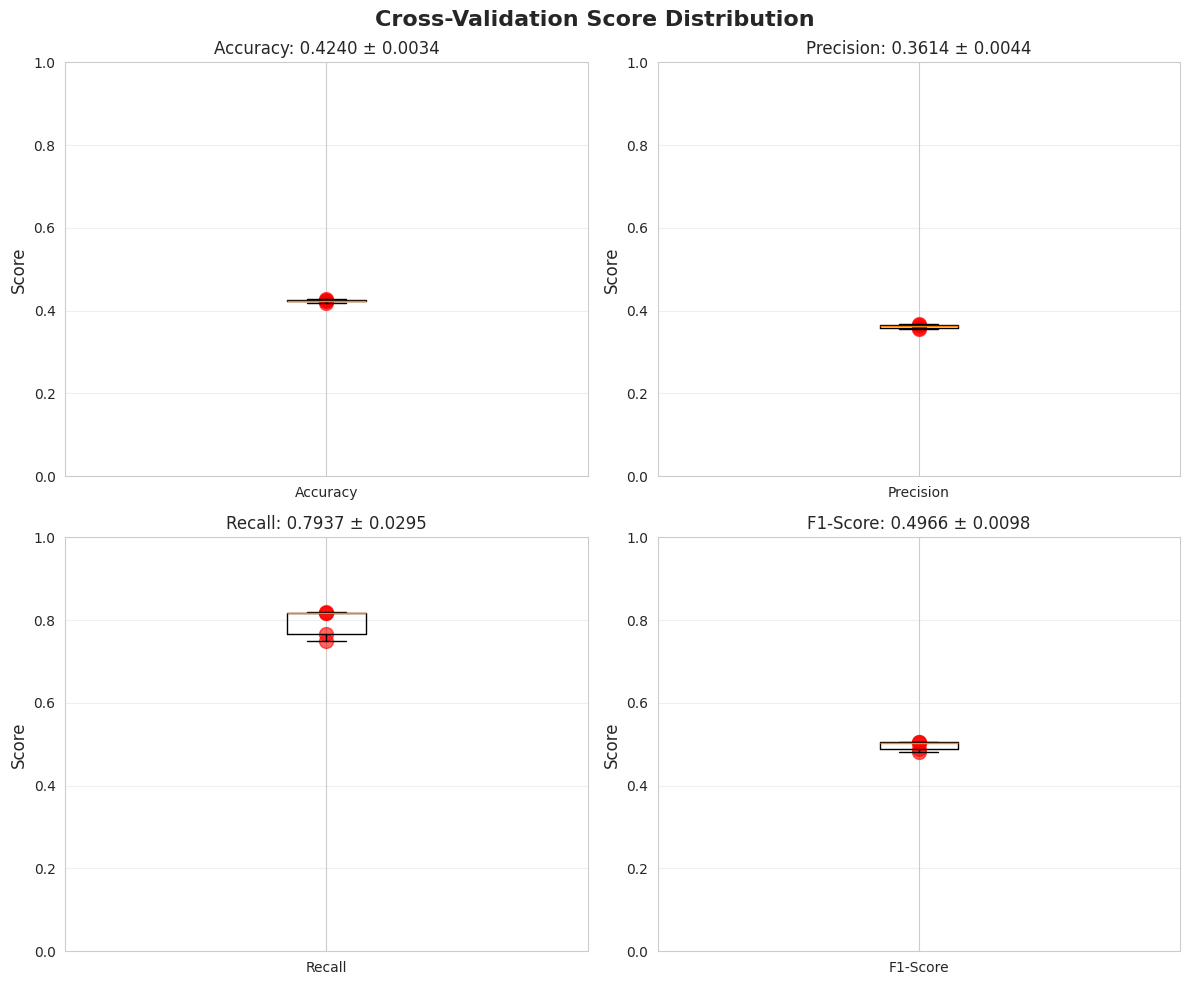

In [51]:
# Perform 5-fold cross-validation on the best model
cv_scores_accuracy = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_scores_precision = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='precision')
cv_scores_recall = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='recall')
cv_scores_f1 = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')

print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"Accuracy:  {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std() * 2:.4f})")
print(f"Precision: {cv_scores_precision.mean():.4f} (+/- {cv_scores_precision.std() * 2:.4f})")
print(f"Recall:    {cv_scores_recall.mean():.4f} (+/- {cv_scores_recall.std() * 2:.4f})")
print(f"F1-Score:  {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std() * 2:.4f})")
print("=" * 60)

# Visualize cross-validation scores
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Cross-Validation Score Distribution', fontsize=16, fontweight='bold')

metrics = [
    ('Accuracy', cv_scores_accuracy),
    ('Precision', cv_scores_precision),
    ('Recall', cv_scores_recall),
    ('F1-Score', cv_scores_f1)
]

for idx, (metric_name, scores) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.boxplot([scores], labels=[metric_name])
    ax.scatter([1] * len(scores), scores, alpha=0.6, c='red', s=100)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Feature Importance Analysis

Understanding which features have the most impact on predictions.

In [52]:
# Get feature coefficients from the logistic regression model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("=" * 60)
print("FEATURE IMPORTANCE (sorted by absolute coefficient value)")
print("=" * 60)
print(feature_importance.to_string(index=False))
print("=" * 60)
print("\nInterpretation:")
print("- Positive coefficients → increase risk of heart attack")
print("- Negative coefficients → decrease risk of heart attack")
print("- Larger absolute values → stronger influence on prediction")

FEATURE IMPORTANCE (sorted by absolute coefficient value)
                        Feature  Coefficient  Abs_Coefficient
            Sleep Hours Per Day    -0.056137         0.056137
                   Diastolic_BP    -0.041633         0.041633
                        Obesity    -0.034544         0.034544
                         Income     0.033401         0.033401
                  Triglycerides     0.033173         0.033173
                    Systolic_BP     0.030076         0.030076
        Exercise Hours Per Week     0.028529         0.028529
                    Cholesterol     0.027038         0.027038
            Alcohol Consumption    -0.026970         0.026970
                       Diabetes     0.025441         0.025441
                   Stress Level    -0.025402         0.025402
                            Age     0.024333         0.024333
                     Heart Rate    -0.023504         0.023504
                        Smoking    -0.017035         0.017035
        Sede

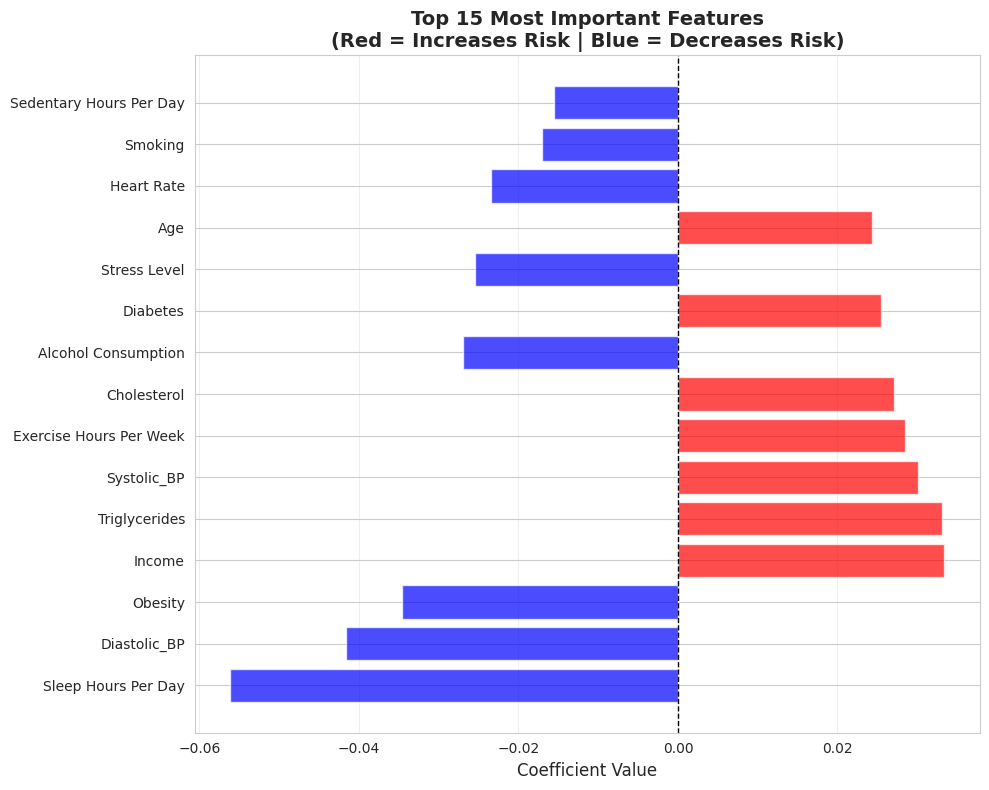

In [53]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_n = 15  # Show top 15 features
top_features = feature_importance.head(top_n)

colors = ['red' if x > 0 else 'blue' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title(f'Top {top_n} Most Important Features\n(Red = Increases Risk | Blue = Decreases Risk)',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Save the Trained Model and Scaler

In [54]:
# Save the trained model
joblib.dump(best_model, 'logistic_regression_model.pkl')
print("✓ Trained model saved as 'logistic_regression_model.pkl'")

# Save the scaler (needed for preprocessing new data)
joblib.dump(scaler, 'scaler.pkl')
print("✓ Scaler saved as 'scaler.pkl'")

# Save feature names for reference
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
print("✓ Feature names saved as 'feature_names.pkl'")

print("\n📦 All model artifacts saved successfully!")

✓ Trained model saved as 'logistic_regression_model.pkl'
✓ Scaler saved as 'scaler.pkl'
✓ Feature names saved as 'feature_names.pkl'

📦 All model artifacts saved successfully!


## 15. Model Testing with Sample Data

In [55]:
# Create sample test cases
sample_data = pd.DataFrame({
    # Feature names must match training data
    'Age': [25, 55, 70],
    'Sex': [1, 0, 1],  # Male, Female, Male
    'Cholesterol': [180, 240, 300],
    'Heart Rate': [70, 85, 95],
    'Diabetes': [0, 1, 1],
    'Family History': [0, 1, 1],
    'Smoking': [0, 1, 1],
    'Obesity': [0, 1, 1],
    'Alcohol Consumption': [0, 1, 1],
    'Exercise Hours Per Week': [5, 2, 1],
    'Diet': [2, 1, 0],  # Healthy, Average, Unhealthy
    'Previous Heart Problems': [0, 0, 1],
    'Medication Use': [0, 1, 1],
    'Stress Level': [3, 7, 9],
    'Sedentary Hours Per Day': [4, 8, 10],
    'Income': [60000, 45000, 30000],
    'BMI': [22.5, 28.5, 32.0],
    'Triglycerides': [150, 200, 280],
    'Physical Activity Days Per Week': [5, 2, 1],
    'Sleep Hours Per Day': [8, 6, 5],
    'Systolic_BP': [115, 140, 160],
    'Diastolic_BP': [75, 90, 100]
})

# Scale the sample data
sample_data_scaled = scaler.transform(sample_data)

# Make predictions
sample_predictions = best_model.predict(sample_data_scaled)
sample_probabilities = best_model.predict_proba(sample_data_scaled)[:, 1]

# Display results
print("=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)
for i in range(len(sample_data)):
    print(f"\nPatient {i+1}:")
    print(f"  Age: {sample_data.iloc[i]['Age']}, Cholesterol: {sample_data.iloc[i]['Cholesterol']}, BMI: {sample_data.iloc[i]['BMI']}")
    print(f"  Prediction: {'HIGH RISK ⚠️' if sample_predictions[i] == 1 else 'Low Risk ✓'}")
    print(f"  Probability of High Risk: {sample_probabilities[i]:.2%}")
print("=" * 80)

SAMPLE PREDICTIONS

Patient 1:
  Age: 25.0, Cholesterol: 180.0, BMI: 22.5
  Prediction: HIGH RISK ⚠️
  Probability of High Risk: 51.80%

Patient 2:
  Age: 55.0, Cholesterol: 240.0, BMI: 28.5
  Prediction: Low Risk ✓
  Probability of High Risk: 47.84%

Patient 3:
  Age: 70.0, Cholesterol: 300.0, BMI: 32.0
  Prediction: Low Risk ✓
  Probability of High Risk: 48.53%


## 16. Summary and Recommendations

In [56]:
print("="*80)
print("MODEL TRAINING SUMMARY")
print("="*80)
print(f"\n✓ Dataset: {len(df)} patients, {X.shape[1]} features")
print(f"✓ Model: Logistic Regression (optimized for Recall)")
print(f"✓ Training set: {len(X_train)} samples")
print(f"✓ Testing set: {len(X_test)} samples")
print(f"\n📊 FINAL MODEL PERFORMANCE:")
print(f"   - Recall: {recall_tuned:.4f} (Priority metric - minimizing missed heart attacks)")
print(f"   - Precision: {precision_tuned:.4f}")
print(f"   - F1-Score: {f1_tuned:.4f}")
print(f"   - Accuracy: {accuracy_tuned:.4f}")
print(f"\n🔧 BEST HYPERPARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")
print(f"\n📁 SAVED FILES:")
print(f"   - logistic_regression_model.pkl (trained model)")
print(f"   - scaler.pkl (feature scaler)")
print(f"   - feature_names.pkl (feature list)")
print(f"   - confusion_matrix_baseline.png")
print(f"   - roc_curve_baseline.png")
print(f"   - model_comparison.png")
print(f"   - cross_validation_results.png")
print(f"   - feature_importance.png")
print(f"\n💡 KEY INSIGHTS:")
print(f"   - Model prioritizes RECALL to minimize missed heart attack diagnoses")
print(f"   - False Negatives reduced to {cm_tuned[1,0]} (critical for patient safety)")
print(f"   - Top risk factors identified through feature importance analysis")
print(f"   - Model is interpretable - coefficients show feature impact")
print("="*80)

MODEL TRAINING SUMMARY

✓ Dataset: 8763 patients, 22 features
✓ Model: Logistic Regression (optimized for Recall)
✓ Training set: 7010 samples
✓ Testing set: 1753 samples

📊 FINAL MODEL PERFORMANCE:
   - Recall: 0.8217 (Priority metric - minimizing missed heart attacks)
   - Precision: 0.3598
   - F1-Score: 0.5005
   - Accuracy: 0.4124

🔧 BEST HYPERPARAMETERS:
   - C: 0.1
   - class_weight: {0: 1, 1: 2.0}
   - penalty: l2
   - solver: lbfgs

📁 SAVED FILES:
   - logistic_regression_model.pkl (trained model)
   - scaler.pkl (feature scaler)
   - feature_names.pkl (feature list)
   - confusion_matrix_baseline.png
   - roc_curve_baseline.png
   - model_comparison.png
   - cross_validation_results.png
   - feature_importance.png

💡 KEY INSIGHTS:
   - Model prioritizes RECALL to minimize missed heart attack diagnoses
   - False Negatives reduced to 112 (critical for patient safety)
   - Top risk factors identified through feature importance analysis
   - Model is interpretable - coefficients

# **Phase 4:**
***Visualizing the Raw Data***

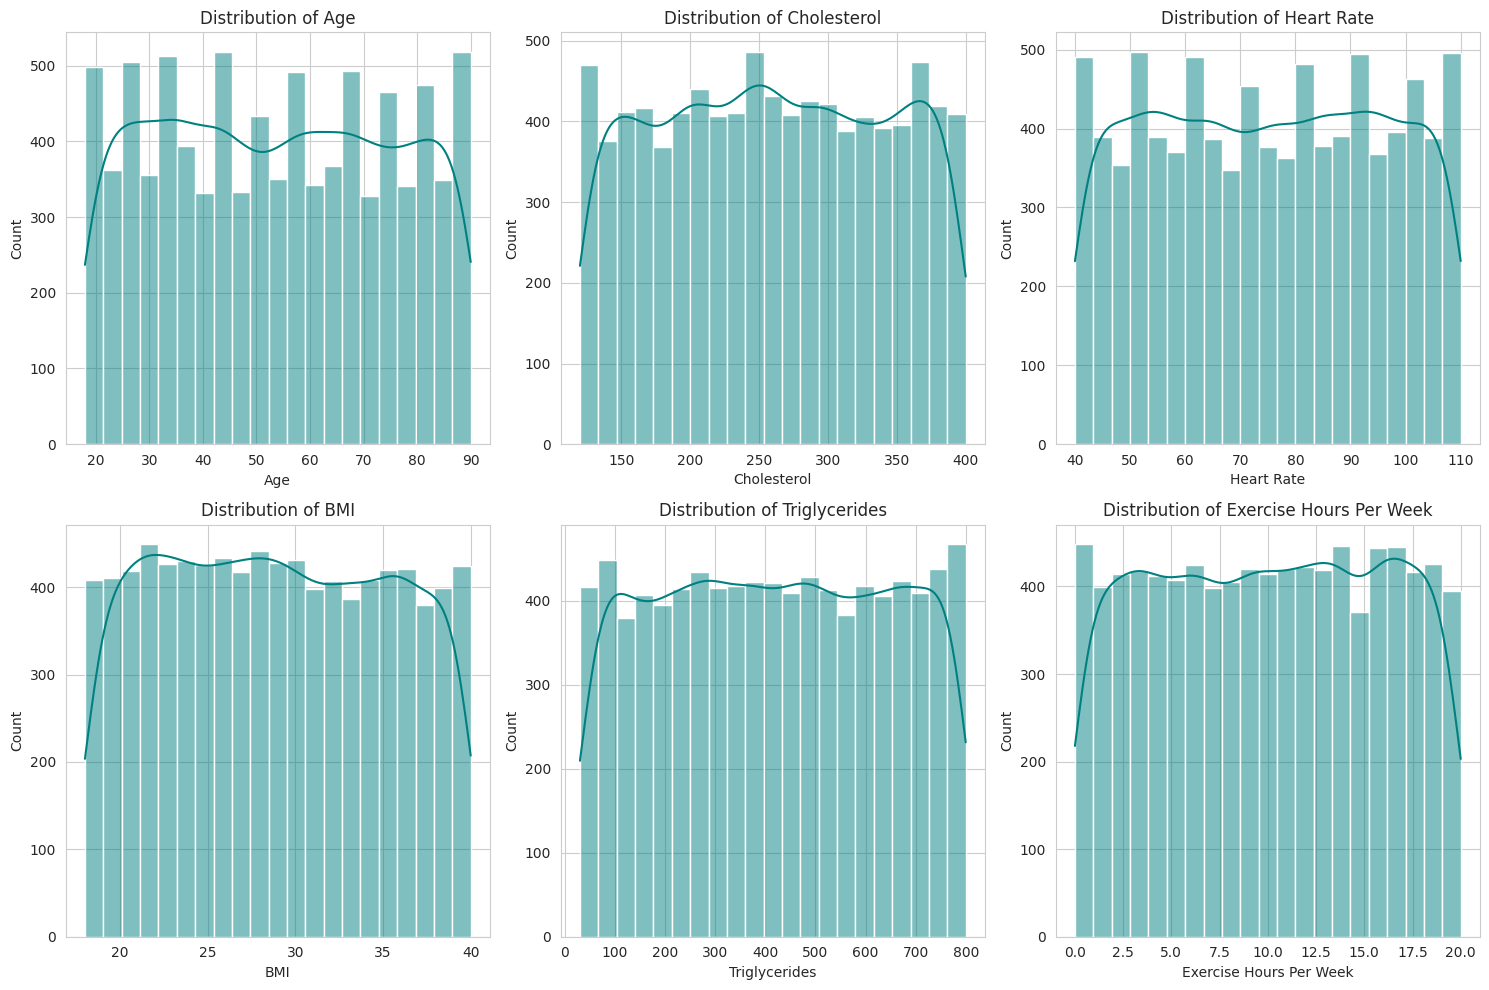

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Key Numerical Features
# We check how health metrics like Age, Cholesterol, and BMI are distributed.
cols_to_plot = ['Age', 'Cholesterol', 'Heart Rate', 'BMI', 'Triglycerides', 'Exercise Hours Per Week']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_clean[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# **Phase 4:**
***Feature Important Analysis***

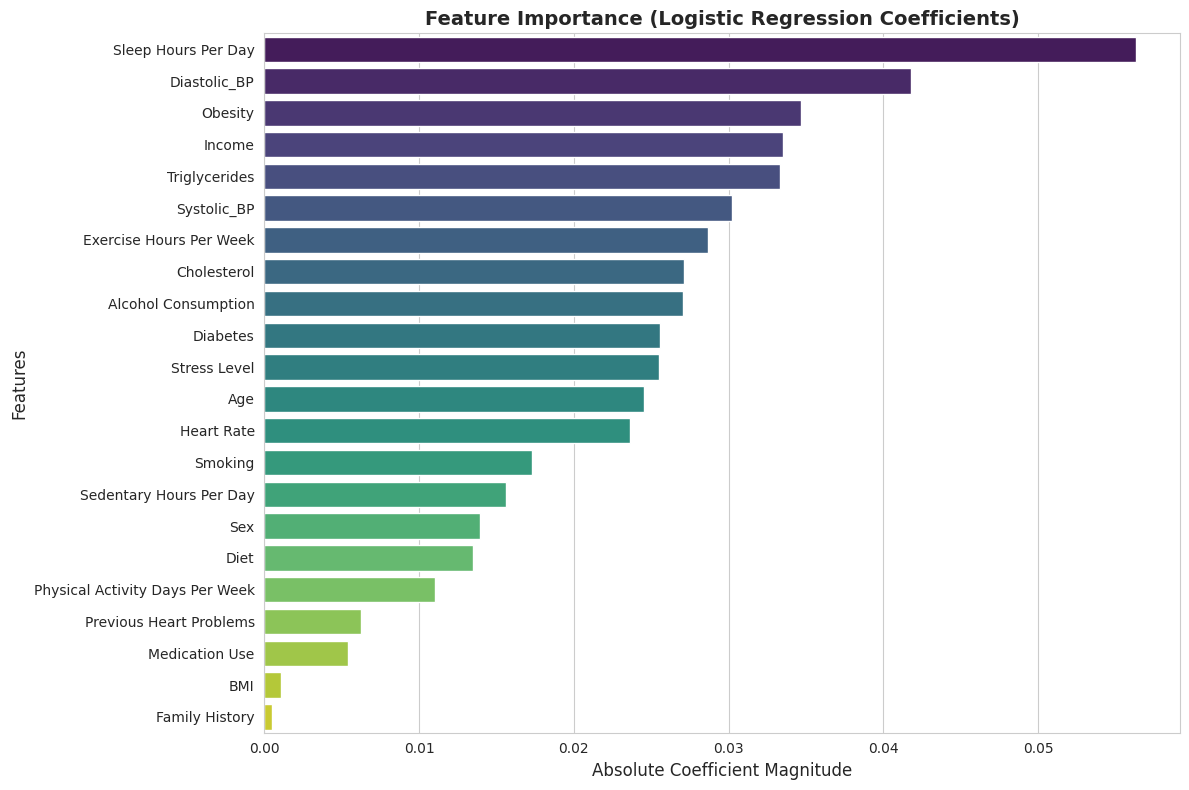

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Extract feature names and coefficients
feature_names = X.columns
# Use absolute values to show magnitude of impact
coefficients = np.abs(baseline_model.coef_[0])

# 2. Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

# 3. Plot Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Coefficient Magnitude', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

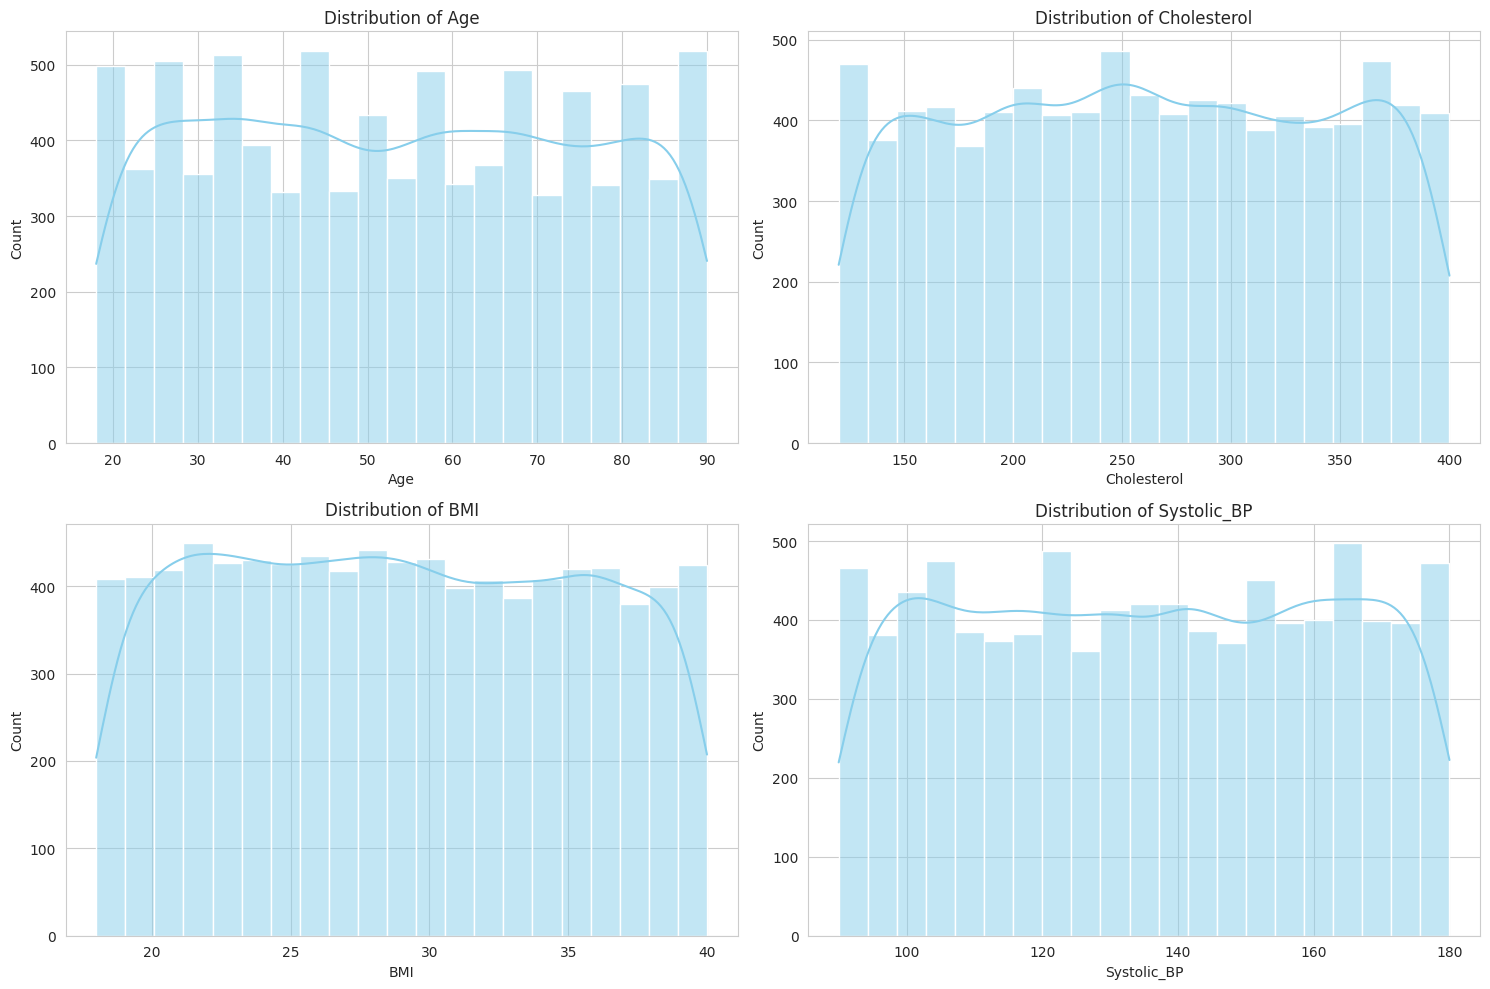

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histograms: Are things spread out normally?
# Let's check Age, Cholesterol, and BMI
features_to_plot = ['Age', 'Cholesterol', 'BMI', 'Systolic_BP']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


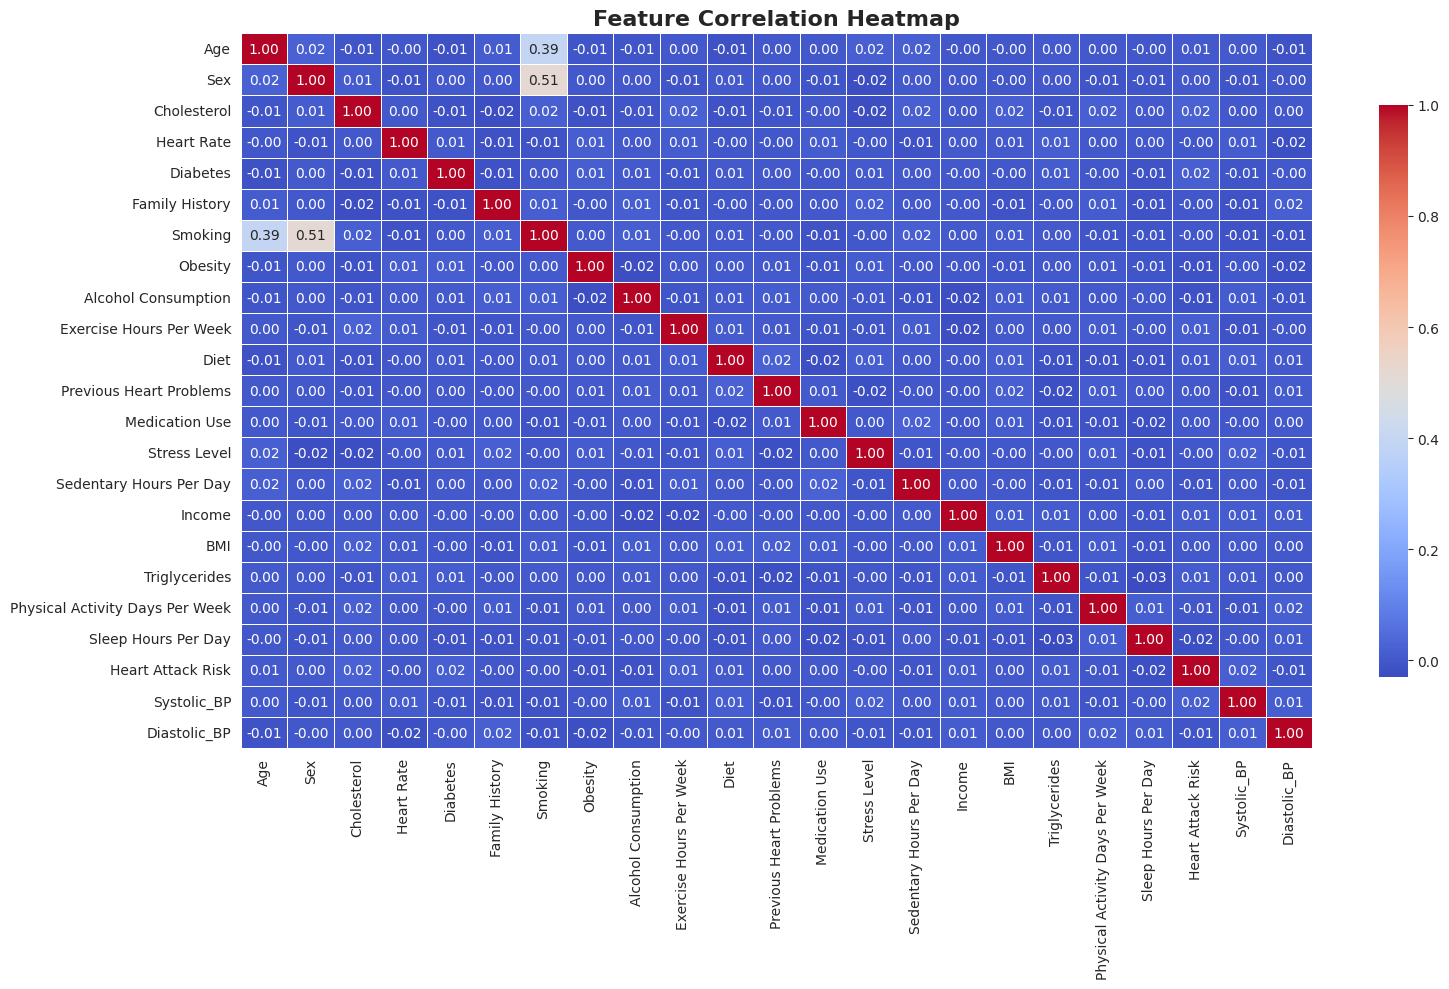

In [60]:
# 1. Calculate correlation matrix for the cleaned dataset
# Using df_clean from your Step 3
plt.figure(figsize=(16, 10))
correlation_matrix = df_clean.corr()

# 2. Plot Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()